In [ ]:
!pip install pydicom
!pip install tqdm

     |████████████████████████████████| 35.5MB 90kB/s 


In [ ]:
import numpy as np
import pandas as pd
import pydicom
import os
import scipy.ndimage
import matplotlib.pyplot as plt
from random import shuffle
from tqdm import tqdm

from skimage import measure, morphology
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

In [ ]:
train_dir = '/C/Patient1'
f = open('Patient1.txt', 'w')

dirs = os.listdir(train_dir)
for img_pt in sorted(tqdm(dirs)):
	path = train_dir + '/' + img_pt
	print(path)
	f.write(path)
	f.write('\n')
f.close()

In [ ]:
pfile = open(r"/C/Patient1.txt")
pfile_list = pfile.readlines()
print(pfile_list)
RefDs = pydicom.read_file(pfile_list[0][:-1])

['/C/Patient1/1-01.dcm\n', '/C/Patient1/1-02.dcm\n', '/C/Patient1/1-03.dcm\n', '/C/Patient1/1-04.dcm\n', '/C/Patient1/1-05.dcm\n', '/C/Patient1/1-06.dcm\n', '/C/Patient1/1-07.dcm\n', '/C/Patient1/1-08.dcm\n', '/C/Patient1/1-09.dcm\n', '/C/Patient1/1-10.dcm\n', '/C/Patient1/1-11.dcm\n', '/C/Patient1/1-12.dcm\n', '/C/Patient1/1-13.dcm\n', '/C/Patient1/1-14.dcm\n', '/C/Patient1/1-15.dcm\n', '/C/Patient1/1-16.dcm\n', '/C/Patient1/1-17.dcm\n', '/C/Patient1/1-18.dcm\n', '/C/Patient1/1-19.dcm\n', '/C/Patient1/1-20.dcm\n', '/C/Patient1/1-21.dcm\n', '/C/Patient1/1-22.dcm\n', '/C/Patient1/1-23.dcm\n', '/C/Patient1/1-24.dcm\n', '/C/Patient1/1-25.dcm\n', '/C/Patient1/1-26.dcm\n', '/C/Patient1/1-27.dcm\n', '/C/Patient1/1-28.dcm\n', '/C/Patient1/1-29.dcm\n', '/C/Patient1/1-30.dcm\n', '/C/Patient1/1-31.dcm\n', '/C/Patient1/1-32.dcm\n', '/C/Patient1/1-33.dcm\n', '/C/Patient1/1-34.dcm\n', '/C/Patient1/1-35.dcm\n', '/C/Patient1/1-36.dcm\n', '/C/Patient1/1-37.dcm\n', '/C/Patient1/1-38.dcm\n', '/C/Patient

In [ ]:
def load_scan(path):
    slices = [pydicom.read_file(path + '/' + s) for s in os.listdir(path)]
    slices.sort(key = lambda x: int(x.InstanceNumber))
    try:
        slice_thickness = np.abs(slices[0].ImagePositionPatient[2] - slices[1].ImagePositionPatient[2])
    except:
        slice_thickness = np.abs(slices[0].SliceLocation - slices[1].SliceLocation)

    for s in slices:
        s.SliceThickness = slice_thickness

    return slices

In [ ]:
def get_pixels_hu(scans):
    image = np.stack([s.pixel_array for s in scans])
    image = image.astype(np.int16)

    image[image == -2000] = 0

    intercept = scans[0].RescaleIntercept
    slope = scans[0].RescaleSlope

    if slope != 1:
        image = slope * image.astype(np.float64)
        image = image.astype(np.int16)

    image += np.int16(intercept)

    return np.array(image, dtype=np.int16)

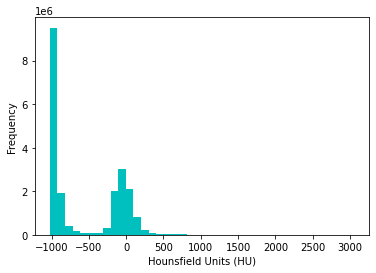

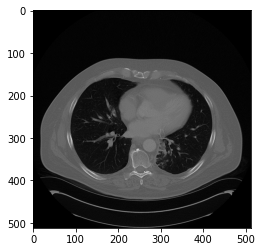

In [ ]:
first_patient = [pydicom.read_file(filenameDCM[:-1])for filenameDCM in pfile_list]
first_patient_pixels = get_pixels_hu(first_patient)
plt.hist(first_patient_pixels.flatten(), bins=40, color='c')
plt.xlabel("Hounsfield Units (HU)")
plt.ylabel("Frequency")
plt.show()
plt.imshow(first_patient_pixels[40], cmap=plt.cm.gray)
plt.show()

In [ ]:
def resample(image, scan, new_spacing=[1,1,1]):
    # Determine current pixel spacing
    spacing = np.array([scan[0].SliceThickness] + list(scan[0].PixelSpacing), dtype=np.float32)

    resize_factor = spacing / new_spacing
    new_real_shape = image.shape * resize_factor
    new_shape = np.round(new_real_shape)
    real_resize_factor = new_shape / image.shape
    new_spacing = spacing / real_resize_factor

    image = scipy.ndimage.interpolation.zoom(image, real_resize_factor, mode='nearest')

    return image, new_spacing

In [ ]:
pix_resampled, spacing = resample(first_patient_pixels, first_patient, new_spacing=[1,1,1])
print("Shape before resampling\t", first_patient_pixels.shape)
print("Shape after resampling\t", pix_resampled.shape)

Shape before resampling	 (80, 512, 512)
Shape after resampling	 (400, 462, 462)


In [ ]:
from skimage import measure
def make_mesh(image, threshold=+30, step_size=1):
  print ("Transposing surface")
  p = image.transpose(2, 1, 0)

  print ("Calculating surface")

  verts, faces, norm, val = measure.marching_cubes_lewiner(p, threshold, step_size=step_size, allow_degenerate=True)
  return verts, faces

make_mesh(pix_resampled, 400)

Transposing surface
Calculating surface


(array([[ 35.9887 , 384.     , 120.     ],
        [ 36.     , 384.     , 119.875  ],
        [ 36.     , 383.9968 , 120.     ],
        ...,
        [424.0084 , 384.     , 307.     ],
        [424.01453, 384.     , 321.     ],
        [424.01675, 384.     , 322.     ]], dtype=float32),
 array([[      2,       1,       0],
        [      4,       3,       0],
        [      0,       3,       2],
        ...,
        [1023138, 1023177, 1023139],
        [1023139, 1023177, 1023178],
        [1023139, 1023178, 1023100]], dtype=int32))

In [ ]:
def plot_3d(image, threshold=-100):

    # Position the scan upright,
    # so the head of the patient would be at the top facing the camera
    p = image.transpose(2,1,0)
    p = p[:,:,::-1]

    verts, faces = measure.marching_cubes_classic(p, threshold)

    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')

    # Fancy indexing: `verts[faces]` to generate a collection of triangles
    mesh = Poly3DCollection(verts[faces], alpha=0.1)
    face_color = [0.5, 0.5, 1]
    mesh.set_facecolor(face_color)
    ax.add_collection3d(mesh)

    ax.set_xlim(0, p.shape[0])
    ax.set_ylim(0, p.shape[1])
    ax.set_zlim(0, p.shape[2])

    plt.show()

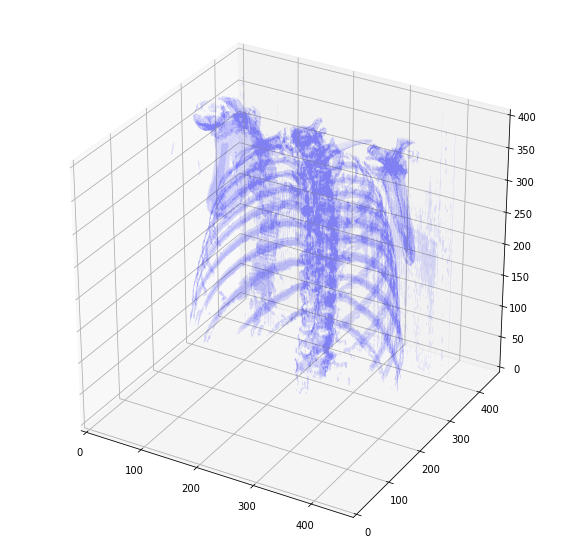

In [ ]:
plot_3d(pix_resampled, 400)

In [ ]:
def largest_label_volume(im, bg=-1):
    vals, counts = np.unique(im, return_counts=True)

    counts = counts[vals != bg]
    vals = vals[vals != bg]

    if len(counts) > 0:
        return vals[np.argmax(counts)]
    else:
        return None

In [ ]:
def segment_lung_mask(image, fill_lung_structures=True):

    # not actually binary, but 1 and 2.
    # 0 is treated as background, which we do not want
    binary_image = np.array(image > -320, dtype=np.int8)+1
    labels = measure.label(binary_image)

    # Pick the pixel in the very corner to determine which label is air.
    #   Improvement: Pick multiple background labels from around the patient
    #   More resistant to "trays" on which the patient lays cutting the air
    #   around the person in half
    background_label = labels[0,0,0]

    #Fill the air around the person
    binary_image[background_label == labels] = 2


    # Method of filling the lung structures (that is superior to something like
    # morphological closing)
    if fill_lung_structures:
        # For every slice we determine the largest solid structure
        for i, axial_slice in enumerate(binary_image):
            axial_slice = axial_slice - 1
            labeling = measure.label(axial_slice)
            l_max = largest_label_volume(labeling, bg=0)

            if l_max is not None: #This slice contains some lung
                binary_image[i][labeling != l_max] = 1


    binary_image -= 1 #Make the image actual binary
    binary_image = 1-binary_image # Invert it, lungs are now 1

    # Remove other air pockets insided body
    labels = measure.label(binary_image, background=0)
    l_max = largest_label_volume(labels, bg=0)
    if l_max is not None: # There are air pockets
        binary_image[labels != l_max] = 0

    return binary_image

In [ ]:
segmented_lungs = segment_lung_mask(pix_resampled, False)
segmented_lungs_fill = segment_lung_mask(pix_resampled, True)

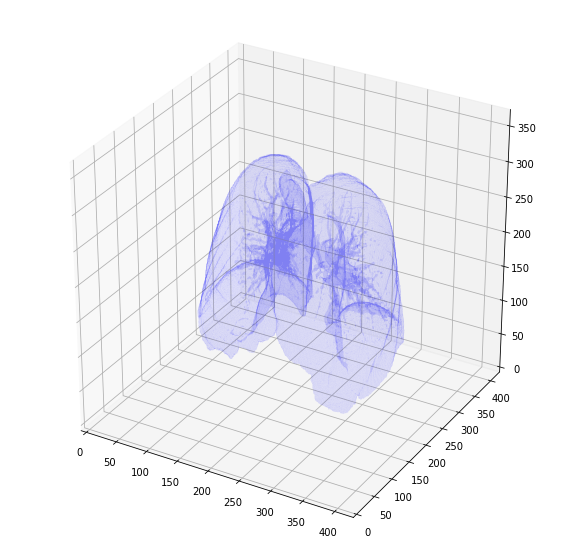

In [ ]:
plot_3d(segmented_lungs, 0)

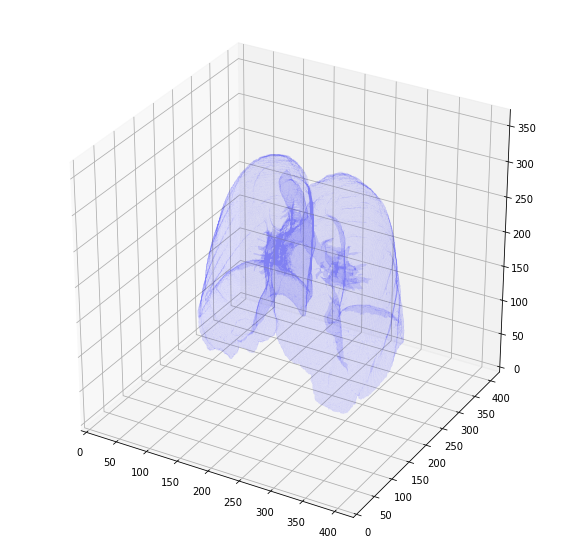

In [ ]:
plot_3d(segmented_lungs_fill, 0)

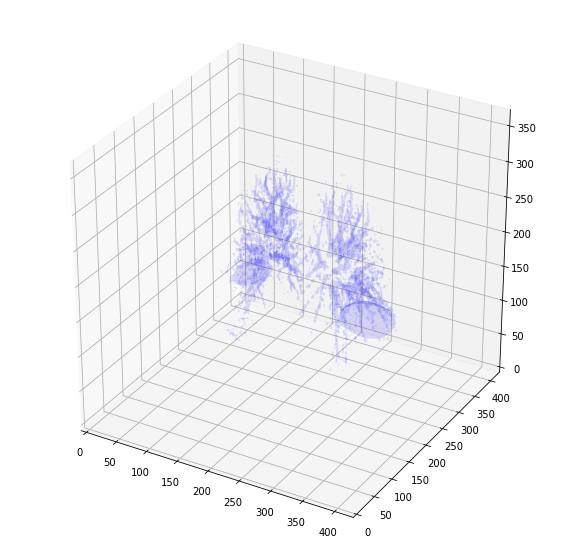

In [ ]:
plot_3d(segmented_lungs_fill - segmented_lungs, 0)